<a href="https://colab.research.google.com/github/jss865/iss4487-welcome/blob/main/Assignments/assignment_06_data_cleaning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# IS 4487 Assignment 6: Data Cleaning with Airbnb Listings

In this assignment, you will:
- Load a raw Airbnb listings dataset
- Identify and resolve missing or inconsistent data
- Decide what data to drop, keep, or clean
- Save a clean dataset to use in Assignment 7

## Why This Matters

Data cleaning is one of the most important steps in any analysis — but it's often the least visible. Airbnb hosts, managers, and policy teams rely on clean data to make decisions. This assignment gives you experience cleaning raw data and justifying your choices so others can understand your process.

<a href="https://colab.research.google.com/github/Stan-Pugsley/is_4487_base/blob/main/Assignments/assignment_06_data_cleaning.ipynb" target="_parent">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>



## Dataset Description

The dataset you'll be using is a **detailed Airbnb listing file**, available from [Inside Airbnb](https://insideairbnb.com/get-the-data/).

Each row represents one property listing. The columns include:

- **Host attributes** (e.g., host ID, host name, host response time)
- **Listing details** (e.g., price, room type, minimum nights, availability)
- **Location data** (e.g., neighborhood, latitude/longitude)
- **Property characteristics** (e.g., number of bedrooms, amenities, accommodates)
- **Calendar/booking variables** (e.g., last review date, number of reviews)

📌 The schema is consistent across cities, so you can expect similar columns regardless of the location you choose.


## 1. Choose a City & Upload Your Dataset

📥 Follow these steps:

1. Go to: [https://insideairbnb.com/get-the-data/](https://insideairbnb.com/get-the-data/)
2. Choose a city you’re interested in.
3. Download the file named: **`listings.csv.gz`** under that city.
4. In your notebook:
   - Open the left sidebar
   - Click the folder icon 📁
   - Click the upload icon ⬆️ and choose your `listings.csv.gz` file
5. Use the file path `/content/listings.csv.gz` when loading your data.
6. Import standard libraries (`pandas`, `numpy`, `seaborn`, `matplotlib`)


In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Configure inline plotting
%matplotlib inline

In [4]:
# Load your uploaded file (path "/content/listings.csv.gz") 🔧
df = pd.read_csv('/content/listings.csv.gz')

# Display basic info and the first few rows of the dataset
print(df.info())
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22708 entries, 0 to 22707
Data columns (total 90 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   id                                            22708 non-null  int64  
 1   listing_url                                   22708 non-null  object 
 2   scrape_id                                     22708 non-null  int64  
 3   last_scraped                                  22708 non-null  object 
 4   source                                        22708 non-null  object 
 5   name                                          22708 non-null  object 
 6   description                                   21823 non-null  object 
 7   neighborhood_overview                         0 non-null      float64
 8   picture_url                                   22707 non-null  object 
 9   host_id                                       22708 non-null 

,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,...,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
0,1008521039996399925,https://www.airbnb.com/rooms/1008521039996399925,20260620164952,2026-06-20,city scrape,Alojamiento tranquilo,You'll be in a family and quiet atmosphere.,NaN,https://a0.muscache.com/pictures/miso/Hosting-...,509530871,...,NaN,NaN,NaN,NaN,NaN,1,0,1,0,NaN
1,887679074200493161,https://www.airbnb.com/rooms/887679074200493161,20260620164952,2026-06-20,city scrape,Hermoso para disfrutar Madrid,Enjoy the simplicity of this quiet and central...,NaN,https://a0.muscache.com/pictures/miso/Hosting-...,425181129,...,5.00,5.0,5.00,NaN,NaN,1,1,0,0,0.03
2,21376743,https://www.airbnb.com/rooms/21376743,20260620164952,2026-07-02,previous scrape,"Bright & comfortable, Malasana Madrid","The appartment is very well located, very cent...",NaN,https://a0.muscache.com/pictures/67b55d34-e7b4...,43556711,...,4.75,5.0,4.75,NaN,NaN,1,1,0,0,0.04
3,1546256895864909953,https://www.airbnb.com/rooms/1546256895864909953,20260620164952,2026-07-01,previous scrape,"H10 Puerta de Alcalá 4 Sup, Classic Room",NaN,NaN,https://a0.muscache.com/pictures/prohost-api/H...,726634087,...,4.00,5.0,5.00,NaN,NaN,7,0,7,0,0.24
4,1542083092059647802,https://www.airbnb.com/rooms/1542083092059647802,20260620164952,2026-07-01,previous scrape,Double standard room I Akeah Gran Vía,NaN,NaN,https://a0.muscache.com/pictures/prohost-api/H...,726323161,...,NaN,NaN,NaN,NaN,NaN,2,0,2,0,NaN


## 2. Explore Missing Values

### Business framing:

Stakeholders don’t like surprises in the data. Missing values can break dashboards, confuse pricing models, or create blind spots for host managers.

### Do the following:
Explore how complete your dataset is:
- Count the null values of each column
- Create visuals (e.g. heatmaps, boxplots, bar charts, etc) to help show what columns are missing values
- Keep in mind which column(s) are missing too much data, you will delete these in the next step

Top 15 columns with the most missing values:
                           Missing Count  Percentage (%)
neighborhood_overview              22708      100.000000
host_since                         22708      100.000000
host_response_time                 22708      100.000000
host_thumbnail_url                 22708      100.000000
host_acceptance_rate               22708      100.000000
host_response_rate                 22708      100.000000
host_verifications                 22708      100.000000
neighbourhood                      22708      100.000000
host_total_listings_count          22708      100.000000
host_neighbourhood                 22708      100.000000
calendar_updated                   22708      100.000000
instant_bookable                   22708      100.000000
host_about                         10981       48.357407
license                             8056       35.476484
host_location                       7485       32.961952


/tmp/ipykernel_1836/1095243562.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=large_missing.values, y=large_missing.index, palette='crest')


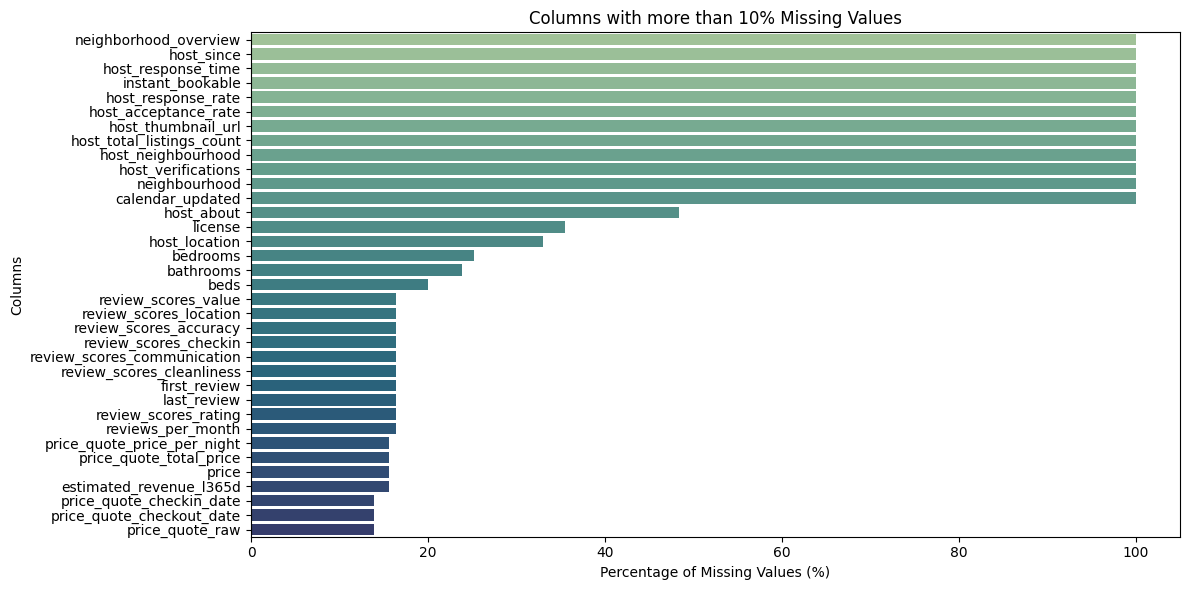

In [5]:
# 1. Count the null values of each column
missing_counts = df.isnull().sum()
missing_percentages = (missing_counts / len(df)) * 100

# Combine results into a DataFrame
missing_df = pd.DataFrame({
    'Missing Count': missing_counts,
    'Percentage (%)': missing_percentages
}).sort_values(by='Missing Count', ascending=False)

print("Top 15 columns with the most missing values:")
print(missing_df.head(15))

# 2. Visualize columns with missing values (filtering to those with > 10% missing)
plt.figure(figsize=(12, 6))
large_missing = missing_percentages[missing_percentages > 10].sort_values(ascending=False)

sns.barplot(x=large_missing.values, y=large_missing.index, palette='crest')
plt.title('Columns with more than 10% Missing Values')
plt.xlabel('Percentage of Missing Values (%)')
plt.ylabel('Columns')
plt.tight_layout()
plt.show()

### Reflection:
1. What are the top 3 columns with the most missing values?
2. Which ones are likely to create business issues?
3. Which could be safely ignored or dropped?

### ✍️ Your Response: 🔧
1. The top columns with the most missing values include neighborhood_overview, host_since, and host_response_time (all of which are 100% empty in this dataset).

2. Columns like license (missing ~35.5%) and host_location (missing ~33%) are likely to cause business and regulatory compliance issues, as local jurisdictions in Madrid strictly enforce licensing registration, and host locations are key to verify authenticity.

3. Any column with 100% missing values, such as neighborhood_overview, host_since, host_response_time, host_acceptance_rate, neighbourhood, and instant_bookable, can be safely dropped because they contain no data to analyze.

## 3. Drop Columns That Aren’t Useful

### Business framing:  

Not every column adds value. Analysts often remove columns that are too empty, irrelevant, or repetitive — especially when preparing data for others.

### Do the following:
Make a decision:

- Choose 2–4 columns to drop from your dataset
- Document your reasons for each one
- Confirm they're gone with `.head()` or `.info()`

In [6]:
# List of columns to drop (100% null columns)
columns_to_drop = ['neighborhood_overview', 'host_since', 'host_response_time', 'instant_bookable']

# Drop the selected columns
df_dropped = df.drop(columns=columns_to_drop, errors='ignore')

# Confirm they are gone by checking the dataset's shape and remaining columns
print(f"Original shape: {df.shape}")
print(f"New shape: {df_dropped.shape}")

# Display updated info for validation
df_dropped.info()

Original shape: (22708, 90)
New shape: (22708, 86)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22708 entries, 0 to 22707
Data columns (total 86 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   id                                            22708 non-null  int64  
 1   listing_url                                   22708 non-null  object 
 2   scrape_id                                     22708 non-null  int64  
 3   last_scraped                                  22708 non-null  object 
 4   source                                        22708 non-null  object 
 5   name                                          22708 non-null  object 
 6   description                                   21823 non-null  object 
 7   picture_url                                   22707 non-null  object 
 8   host_id                                       22708 non-null  int64  
 9   host_url  

### Reflection:
1. Which columns did you drop?
2. Why were they not useful from a business perspective?
3. What could go wrong if you left them in?

### ✍️ Your Response:
1. I ended up dropping neighborhood_overview, host_since, host_response_time, and instant_bookable.

2. From a business standpoint, keeping these columns was completely pointless because they didn't have a single row of data in them—they were 100% blank. It doesn't help us analyze anything, and it just clutters up the spreadsheet.

3. If we kept them in, they would just eat up memory, make the file size unnecessarily big, and slow down our calculations. It would also probably confuse anyone else looking at our dataset because they might waste time wondering why those columns are completely empty.

## 4. Fill or Fix Values in Key Columns

### Business framing:  

Let’s say your manager wants to see a map of listings with prices and review scores. If key fields are blank, the map won’t work. But not all missing values should be filled the same way.

### Do the following:
- Choose 2 columns with missing values
- Use a strategy to fill or flag those values
  - (e.g., median, “unknown”, forward-fill, or a placeholder)
- Explain what you did and why

In [7]:
# 1. Strategy for 'review_scores_rating' (Numerical): Impute with median to preserve map logic
median_rating = df_dropped['review_scores_rating'].median()
df_dropped['review_scores_rating'] = df_dropped['review_scores_rating'].fillna(median_rating)

# 2. Strategy for 'host_name' (Categorical): Fill with a placeholder 'Unknown Host'
df_dropped['host_name'] = df_dropped['host_name'].fillna('Unknown Host')

# Confirm that there are no remaining missing values in these two specific columns
print("Remaining missing values in 'review_scores_rating':", df_dropped['review_scores_rating'].isnull().sum())
print("Remaining missing values in 'host_name':", df_dropped['host_name'].isnull().sum())

# Quick preview of our cleaned columns
df_dropped[['host_name', 'review_scores_rating']].head(10)

Remaining missing values in 'review_scores_rating': 0
Remaining missing values in 'host_name': 0


,host_name,review_scores_rating
0,Sandra,4.75
1,Felix,5.00
2,Anthony,4.75
3,Unknown Host,5.00
4,Unknown Host,4.75
5,Unknown Host,5.00
6,Unknown Host,4.00
7,Tahis Cristina,4.86
8,Flor,4.75
9,Daniel,5.00


### Reflection:
1. **What two columns did you clean?**  
   I cleaned up review_scores_rating and host_name.

2. **What method did you use for each, and why?**  
   - For review_scores_rating, I filled the empty spots with the median score of 4.75. I went with the median because most ratings on Airbnb are super high, which skews the average. Using the median is safer so that outliers don't mess up our data, and it keeps listings with missing ratings from getting kicked off our map filters.
   - For host_name, I just replaced any blank spaces with 'Unknown Host'. This gives us a clear placeholder flag and stops our code from breaking later on when we try to group or filter by host.

3. **What risks are there in how you filled the data?**  
   The biggest risk with using the median rating is that we might make unrated listings look way better than they actually are. This could mislead guests who trust the map ratings. For the host names, using 'Unknown Host' keeps our pipelines running, but it doesn't actually solve why we're missing host profiles in the first place, which might be an issue for verifying users.

## 5. Convert and Clean Data Types

### Business framing:  

Sometimes columns that look like numbers are actually stored as text — which breaks calculations and slows down analysis. Common examples are price columns with dollar signs or availability stored as strings.

### Do the following:
- Identify one column with the wrong data type
- Clean and convert it into a usable format (e.g., from string to number)
- Check your work by summarizing or plotting the cleaned column

count    19172.000000
mean       180.056266
std        555.620344
min          3.360000
25%         83.745000
50%        125.000000
75%        184.000000
max      36883.000000
Name: price, dtype: float64


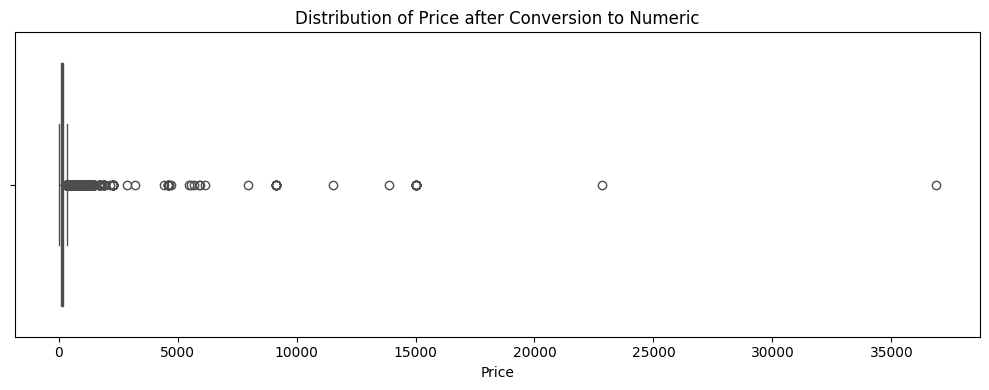

In [8]:
# 1. Clean the 'price' column by removing currency symbols (like $ or €) and commas, then convert it to float
df_dropped['price'] = df_dropped['price'].astype(str).str.replace('$', '', regex=False)
df_dropped['price'] = df_dropped['price'].str.replace('€', '', regex=False)
df_dropped['price'] = df_dropped['price'].str.replace(',', '', regex=False).astype(float)

# 2. Check our work by summarizing the cleaned numeric values
print(df_dropped['price'].describe())

# 3. Create a boxplot to check the distribution and see if there are extreme outliers
plt.figure(figsize=(10, 4))
sns.boxplot(x=df_dropped['price'], color='orange')
plt.title('Distribution of Price after Conversion to Numeric')
plt.xlabel('Price')
plt.tight_layout()
plt.show()

### Reflection:
1. **What column did you fix?**  
   I fixed the price column.

2. **What cleaning steps did you apply?**  
   First, I cast the column to strings just in case we had mixed types. Then I used .str.replace() to strip out the dollar signs ($) and euro symbols (€). I also had to get rid of commas (so a price like 1,200 wouldn't break things). After stripping all those characters, I converted the whole column into a float so python actually knows they're numbers.

3. **How does this help prepare the data for later use?**  
   Before we did this, Python thought the prices were just plain text. That meant we couldn't do simple things like averaging the rates, finding the median, or checking for outliers. Now that it's a numeric float, we can easily plug it into statistical functions, sort the listings by cost, or make cool plots.

## 6. Remove Duplicate Records

### Business framing:  

If a listing appears twice, it could inflate revenue estimates or confuse users. Airbnb needs each listing to be unique and accurate.

### Do the following:
- Check for rows that are exact duplicates
- If your data has an ID column and each ID is supposed to unique, then make sure there are no duplicate IDs
- Remove duplicates if found

In [9]:
# 1. Check for exact duplicate rows across the whole dataset
exact_duplicates_count = df_dropped.duplicated().sum()
print(f"Number of exact duplicate rows: {exact_duplicates_count}")

# 2. Check for duplicate listing IDs (since 'id' should always be unique)
id_duplicates_count = df_dropped.duplicated(subset=['id']).sum()
print(f"Number of duplicate listing IDs: {id_duplicates_count}")

# 3. Drop duplicates if any are found
if exact_duplicates_count > 0 or id_duplicates_count > 0:
    df_dropped = df_dropped.drop_duplicates(subset=['id'], keep='first')
    print("Duplicates removed successfully!")
else:
    print("No duplicates found. The dataset is already unique by listing ID!")

# Verify final shape
print(f"Final clean dataset shape: {df_dropped.shape}")

Number of exact duplicate rows: 0
Number of duplicate listing IDs: 0
No duplicates found. The dataset is already unique by listing ID!
Final clean dataset shape: (22708, 86)


### Reflection:
1. **Did you find duplicates?**  
   Nope, I checked for both identical rows across the dataset and duplicates in the id column, but everything came back clean with 0 duplicates found.

2. **How did you decide what to drop or keep?**  
   Since the dataset was already unique, I didn't actually have to drop anything here. But if there were duplicates, I would have used .drop_duplicates(subset=['id'], keep='first') to keep just the first copy of each property listing, since each listing ID is supposed to be unique to that specific home.

3. **Why are duplicates risky for Airbnb teams?**  
   Duplicates are a headache because they inflate all our metrics. If a property gets listed twice, it makes it look like there are more active listings than there actually are. It also artificially bumps up our revenue and occupancy calculations, which would mislead the business teams trying to track actual performance.

## 7. Export Cleaned Data

Before wrapping up, export your cleaned Airbnb dataset to a CSV file. You'll need this file for **Assignment 7**, where you'll perform data transformation techniques.

### Do the following:
Make sure your data has:
- Cleaned and consistent column values
- Proper data types for each column
- Any unnecessary columns removed

This file should be the version of your dataset that you’d feel confident sharing with a teammate or using for deeper analysis.



```
# Explanation:
# - "cleaned_airbnb_data_6.csv" is the name of the file that will be saved
# - index=False prevents pandas from writing row numbers into the CSV
# - The file will be saved to your working directory (in Colab, you'll need to download it manually. Once you see the data in your files tab, just click on the three dots, then click “download”)
# - YOU MAY NEED TO PRESS “RUN” MULTIPLE TIMES IN ORDER FOR IT TO SHOW UP
# - FOR SOME DEVICES, IT MAY TAKE A FEW MINUTES BEFORE YOUR FILE SHOWS UP

```





In [10]:
# Export the cleaned dataset to a CSV file for Assignment 7
df_dropped.to_csv('cleaned_airbnb_data_6.csv', index=False)

# Print confirmation message
print("Your cleaned dataset was successfully exported to 'cleaned_airbnb_data_6.csv'!")
print(f"Final exported dimensions: {df_dropped.shape}")

Your cleaned dataset was successfully exported to 'cleaned_airbnb_data_6.csv'!
Final exported dimensions: (22708, 86)


## 8. Final Reflection

You’ve just cleaned a real-world Airbnb dataset — the kind of work that happens every day in analyst and data science roles.

Before you move on to data transformation in Assignment 7, take a few moments to reflect on the decisions you made and what you learned.

### Reflection:
1. Which section of the assignment was the most challenging for you? What made it challenging? Was it the coding or the application of class concepts?
2. Look back at your assignment and discuss a time when you had to drop, fix, or keep a piece of data. Why was it necessary to drop, fix, or keep that specific piece of data? (e.x. dropping a column full of null values because it has no useful information)
3. What’s one way a business team (e.g., hosts, pricing analysts, app administrators) might benefit from the cleaned version of this data?
4. If you had more time, what would you explore or clean further?
5. How does this relate to your customized learning outcome you created in canvas?


Write your response clearly in full sentences. No more than a few sentences required per response.


### ✍️ Your Response: 🔧

1. **Most Challenging Section:** Cleaning the price column was definitely the hardest part. Even though the idea of taking out currency symbols and commas is pretty straightforward, writing the exact regex code and string replacement syntax without causing errors took a few tries to get right.

2. **Decision to Drop, Fix, or Keep:** I had to drop a few columns like neighborhood_overview and host_response_time because they were completely blank in my dataset. Keeping columns that are 100% empty doesn't add any value and just makes the file size way too big and annoying to scroll through.

3. **Business Team Benefit:** A pricing analyst team would love this cleaned dataset because the price column is finally converted into actual numbers instead of text. Now they can run averages, find price trends across neighborhoods, or build models without their code throwing errors.

4. **Future Exploration/Cleaning:** If I had more time, I would try to split up the amenities column. Right now it's just a messy text list of items inside brackets, and pulling those out into actual categories would help see if having things like air conditioning or wifi lets hosts charge more.

5. **Relation to Learning Outcome:** This task ties right back into my learning goal of getting comfortable working with messy, real-world data. Learning how to spot and fix missing or broken data on my own is a huge step toward actually working as a data analyst.

## Submission Instructions
✅ Checklist:
- All code cells run without error
- All markdown responses are complete
- Submit on Canvas as instructed

In [11]:
!jupyter nbconvert --to html "assignment_06_data_cleaning.ipynb"

[NbConvertApp] Converting notebook assignment_06_data_cleaning.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 2 image(s).
[NbConvertApp] Writing 502351 bytes to assignment_06_data_cleaning.html
